# Mémoli Distance Profiles and the Gromov--Wasserstein Lower Bound

**Credit.** This notebook is part of *Optimal Transport for Machine Learners* by [Gabriel Peyré](https://www.gpeyre.com/), CNRS and École normale supérieure, PSL University. The book and reproducible sources are available at [github.com/gpeyre/ot4ml](https://github.com/gpeyre/ot4ml).

**Copyright.** Copyright (c) 2026 Gabriel Peyré. Released under the MIT License; see the repository `LICENSE` file.

This notebook generates `fig:gromov-memoli-distance-profiles`. For a metric-measure space $\mathbb X=(\mathcal X,d_{\mathcal X},\alpha)$, each point $x$ is represented by its distance profile

$$
\alpha_x=(d_{\mathcal X}(x,\cdot))_\#\alpha\in\mathcal P(\mathbb R_+).
$$

The figure uses cat and bunny silhouettes to expose the two nested transport levels in Mémoli's lower bound: exact one-dimensional Wasserstein distances compare local profiles, then an outer optimal assignment couples the profile laws.

In [ ]:
# --- OT4ML_COLAB_BOOTSTRAP: standalone local/Colab setup.
from pathlib import Path as _OT4ML_Path
import importlib.util as _OT4ML_importlib_util
import os as _OT4ML_os
import subprocess as _OT4ML_subprocess
import sys as _OT4ML_sys
import urllib.request as _OT4ML_urllib_request


def _ot4ml_find_repo_root():
    """Locate a checkout containing the shared figure-style module.

    Returns:
        Repository root when a checkout is available, otherwise ``None``.
    """
    here = _OT4ML_Path.cwd().resolve()
    for base in (here, *here.parents):
        if (base / "notebooks-figures" / "figure_style.py").exists():
            return base
        if base.name == "notebooks-figures" and (base / "figure_style.py").exists():
            return base.parent
    return None


def _ot4ml_ensure_package(module_name, package_name):
    """Install one missing dependency in the active Colab environment.

    Args:
        module_name: Importable Python module to test.
        package_name: Distribution name passed to ``pip`` when needed.

    Returns:
        ``None``.
    """
    if _OT4ML_importlib_util.find_spec(module_name) is None:
        _OT4ML_subprocess.run(
            [_OT4ML_sys.executable, "-m", "pip", "install", "-q", package_name],
            check=True,
        )


def _ot4ml_download(relative_path, target):
    """Download one small shared file without cloning the full repository.

    Args:
        relative_path: Repository-relative path on the OT4ML website.
        target: Local destination path.

    Returns:
        ``None``.
    """
    if target.exists():
        return
    target.parent.mkdir(parents=True, exist_ok=True)
    bases = (
        "https://raw.githubusercontent.com/gpeyre/ot4ml/main",
        "https://www.gpeyre.com/ot4ml",
    )
    errors = []
    temporary = target.with_suffix(target.suffix + ".tmp")
    for base in bases:
        url = f"{base}/{relative_path}"
        try:
            with _OT4ML_urllib_request.urlopen(url, timeout=30) as response:
                temporary.write_bytes(response.read())
            temporary.replace(target)
            return
        except Exception as error:
            errors.append(f"{url}: {error}")
            temporary.unlink(missing_ok=True)
    details = "\n".join(errors)
    raise RuntimeError(f"Unable to download {relative_path}.\n{details}")


try:
    _OT4ML_IN_COLAB = _OT4ML_importlib_util.find_spec("google.colab") is not None
except ModuleNotFoundError:
    _OT4ML_IN_COLAB = False

_OT4ML_MPLCONFIG = _OT4ML_Path(
    _OT4ML_os.environ.get(
        "MPLCONFIGDIR",
        _OT4ML_Path(_OT4ML_os.environ.get("TMPDIR", "/tmp")) / "mpl-ot4ml",
    )
)
_OT4ML_MPLCONFIG.mkdir(parents=True, exist_ok=True)
_OT4ML_os.environ["MPLCONFIGDIR"] = str(_OT4ML_MPLCONFIG)

_OT4ML_PACKAGES = (
    ('numpy', 'numpy'),
    ('matplotlib', 'matplotlib'),
    ('scipy', 'scipy'),
    ('PIL', 'Pillow'),
    ('IPython', 'ipython'),
)
if _OT4ML_IN_COLAB:
    for _module_name, _package_name in _OT4ML_PACKAGES:
        _ot4ml_ensure_package(_module_name, _package_name)

ROOT = _ot4ml_find_repo_root()
if ROOT is None:
    ROOT = (
        _OT4ML_Path("/content/ot4ml-figure-runtime")
        if _OT4ML_IN_COLAB
        else _OT4ML_Path.cwd() / "ot4ml-figure-runtime"
    )
ROOT = ROOT.resolve()

_OT4ML_REQUIRED_FILES = (
    'notebooks-figures/thumbnails/gromov-memoli-distance-profiles.png',
    'notebooks-figures/assets/bunny.png',
    'notebooks-figures/assets/cat.png',
)
_style_path = ROOT / "notebooks-figures" / "figure_style.py"
_ot4ml_download("notebooks-figures/figure_style.py", _style_path)
for _relative_path in _OT4ML_REQUIRED_FILES:
    _ot4ml_download(_relative_path, ROOT / _relative_path)

(ROOT / "OT4ML" / "figures").mkdir(parents=True, exist_ok=True)
(ROOT / "notebooks-figures" / "thumbnails").mkdir(parents=True, exist_ok=True)
_OT4ML_os.chdir(ROOT)
_figures_path = str(ROOT / "notebooks-figures")
if _figures_path not in _OT4ML_sys.path:
    _OT4ML_sys.path.insert(0, _figures_path)


In [2]:
from pathlib import Path
import logging
import os
import sys


ROOT = Path.cwd()
if (ROOT / "notebooks-figures" / "figure_style.py").exists():
    FIGROOT = ROOT / "notebooks-figures"
elif (ROOT / "figure_style.py").exists():
    FIGROOT = ROOT
    ROOT = FIGROOT.parent
elif (ROOT.parent / "notebooks-figures" / "figure_style.py").exists():
    ROOT = ROOT.parent
    FIGROOT = ROOT / "notebooks-figures"
else:
    raise RuntimeError("Could not locate notebooks-figures/figure_style.py")

if str(FIGROOT) not in sys.path:
    sys.path.insert(0, str(FIGROOT))

import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
from scipy.optimize import linear_sum_assignment
from scipy.spatial.distance import cdist

from figure_style import (
    GRAY,
    figure_dir,
    remove_axes,
    save_pdf,
    setup_matplotlib,
)

setup_matplotlib()
logging.getLogger("fontTools").setLevel(logging.ERROR)

NAME = "gromov-memoli-distance-profiles"
OUT = figure_dir(NAME)
THUMBNAIL = FIGROOT / "thumbnails" / f"{NAME}.png"
ASSET_DIR = FIGROOT / "assets"
CAT_PATH = ASSET_DIR / "cat.png"
BUNNY_PATH = ASSET_DIR / "bunny.png"
N_POINTS = 300
N_REPRESENTATIVES = 8
N_BINS = 20

## Uniform farthest-point samples of two silhouettes

The cat and bunny indicators are resized only to construct dense candidate grids. Greedy farthest-point sampling then selects $n=300$ approximately uniform locations inside each silhouette. We center each cloud and normalize its Euclidean diameter to one, so the comparison emphasizes shape rather than global translation or scale. The resulting metric-measure spaces are

$$
\mathbb X_n=\left(X_n,d_{\mathrm E},\frac1n\sum_{i=1}^n\delta_{x_i}\right),
\qquad
\mathbb Y_n=\left(Y_n,d_{\mathrm E},\frac1n\sum_{j=1}^n\delta_{y_j}\right).
$$

In [3]:
def farthest_point_indices(
    points: np.ndarray,
    n_samples: int,
    start_index: int | None = None,
) -> np.ndarray:
    """Select a deterministic Euclidean farthest-point subset.

    Args:
        points: Candidate locations of shape ``(n_candidates, dimension)``.
        n_samples: Number of distinct indices to select.
        start_index: Optional first index. If omitted, use the point nearest
            the candidate centroid.

    Returns:
        Integer array of selected candidate indices in greedy order.

    Raises:
        ValueError: If the candidate array or requested sample count is invalid.
    """
    points = np.asarray(points, dtype=float)
    if points.ndim != 2 or len(points) == 0:
        raise ValueError("points must be a nonempty two-dimensional array")
    if not 1 <= n_samples <= len(points):
        raise ValueError("n_samples must lie between one and the candidate count")

    if start_index is None:
        centroid = points.mean(axis=0)
        start_index = int(np.argmin(np.sum((points - centroid) ** 2, axis=1)))
    if not 0 <= start_index < len(points):
        raise ValueError("start_index is outside the candidate array")

    selected = np.empty(n_samples, dtype=int)
    selected[0] = start_index
    minimum_squared_distance = np.sum(
        (points - points[start_index]) ** 2,
        axis=1,
    )
    minimum_squared_distance[start_index] = -np.inf

    for sample_index in range(1, n_samples):
        next_index = int(np.argmax(minimum_squared_distance))
        selected[sample_index] = next_index
        squared_distance = np.sum((points - points[next_index]) ** 2, axis=1)
        minimum_squared_distance = np.minimum(
            minimum_squared_distance,
            squared_distance,
        )
        minimum_squared_distance[selected[: sample_index + 1]] = -np.inf
    return selected


def load_silhouette_sample(
    path: Path,
    n_points: int,
    max_resolution: int = 420,
    threshold: float = 0.55,
) -> dict:
    """Load a binary silhouette and sample its interior by farthest points.

    Args:
        path: Image containing a dark silhouette on a light background.
        n_points: Number of interior samples.
        max_resolution: Largest resized image dimension used for candidates.
        threshold: Gray-level threshold in ``[0, 1]`` defining the silhouette.

    Returns:
        Dictionary containing normalized points, the display mask, and the
        normalized mask extent.

    Raises:
        FileNotFoundError: If the silhouette image is unavailable.
        RuntimeError: If thresholding produces too few interior pixels.
    """
    if not path.exists():
        raise FileNotFoundError(f"Missing silhouette asset: {path}")

    with Image.open(path) as image:
        grayscale = image.convert("L")
        resize_factor = max_resolution / max(grayscale.size)
        resized_size = tuple(
            max(2, int(round(size * resize_factor))) for size in grayscale.size
        )
        grayscale = grayscale.resize(resized_size, Image.Resampling.LANCZOS)
        values = np.asarray(grayscale, dtype=float) / 255.0

    mask = values < threshold
    rows, columns = np.nonzero(mask)
    if len(rows) < n_points:
        raise RuntimeError("Thresholded silhouette has too few interior pixels")

    row_min, row_max = rows.min(), rows.max()
    column_min, column_max = columns.min(), columns.max()
    mask = mask[row_min : row_max + 1, column_min : column_max + 1]
    rows, columns = np.nonzero(mask)
    height, width = mask.shape

    # Cartesian coordinates: x points right and y points upward.
    candidates = np.column_stack((columns, height - 1 - rows)).astype(float)
    selected = farthest_point_indices(candidates, n_points)
    sampled = candidates[selected]

    center = candidates.mean(axis=0)
    centered = sampled - center
    diameter = float(cdist(centered, centered).max())
    if diameter <= 0.0:
        raise RuntimeError("Degenerate silhouette sample")
    normalized_points = centered / diameter

    extent = np.array(
        [
            (0.0 - center[0]) / diameter,
            (width - 1.0 - center[0]) / diameter,
            (0.0 - center[1]) / diameter,
            (height - 1.0 - center[1]) / diameter,
        ]
    )
    return {
        "points": normalized_points,
        "mask": mask[::-1].astype(float),
        "extent": extent,
        "path": path,
    }


CAT = load_silhouette_sample(CAT_PATH, N_POINTS)
BUNNY = load_silhouette_sample(BUNNY_PATH, N_POINTS)
X = CAT["points"]
Y = BUNNY["points"]
D_X = cdist(X, X)
D_Y = cdist(Y, Y)

# Remove the tiny FPS discretization error in the diameter normalization.
X /= D_X.max()
Y /= D_Y.max()
CAT["points"] = X
BUNNY["points"] = Y
CAT["extent"] /= D_X.max()
BUNNY["extent"] /= D_Y.max()
D_X = cdist(X, X)
D_Y = cdist(Y, Y)

assert X.shape == Y.shape == (N_POINTS, 2)
assert np.allclose(D_X, D_X.T) and np.allclose(D_Y, D_Y.T)
assert np.allclose(np.diag(D_X), 0.0) and np.allclose(np.diag(D_Y), 0.0)
assert np.isclose(D_X.max(), 1.0) and np.isclose(D_Y.max(), 1.0)

## Exact profile costs and the outer assignment

For uniform clouds of the same cardinality, the profile associated with $x_i$ is the empirical law of the $i$th distance row,

$$
\alpha_{x_i}=\frac1n\sum_{k=1}^n\delta_{(D_X)_{ik}},
\qquad
\beta_{y_j}=\frac1n\sum_{\ell=1}^n\delta_{(D_Y)_{j\ell}}.
$$

If $D_{X,i}^{\uparrow}$ and $D_{Y,j}^{\uparrow}$ denote the sorted rows, one-dimensional monotone transport gives the exact cost

$$
C_{ij}=\mathcal W_2^2(\alpha_{x_i},\beta_{y_j})
=\frac1n\sum_{k=1}^n
\left((D_{X,i}^{\uparrow})_k-(D_{Y,j}^{\uparrow})_k\right)^2.
$$

The outer Wasserstein-over-Wasserstein problem is therefore an equal-weight assignment with cost matrix $C$. Its permutation $T_{\mathrm{prof}}$ realizes the empirical Mémoli lower bound

$$
L_{\mathrm{prof}}^2
=\frac1n\sum_{i=1}^n C_{i,T_{\mathrm{prof}}(i)}
\leq \operatorname{GW}_2(\mathbb X_n,\mathbb Y_n)^2.
$$

No histogram approximation is used here: sorting all $300$ distances in each profile computes every entry of $C$ exactly.

In [4]:
def squared_uniform_profile_costs(
    source_distances: np.ndarray,
    target_distances: np.ndarray,
) -> np.ndarray:
    """Compute exact squared W2 costs between uniform empirical profiles.

    Args:
        source_distances: Source pairwise-distance matrix of shape ``(n, n)``.
        target_distances: Target pairwise-distance matrix of shape ``(m, m)``.
            The current equal-weight assignment requires ``m = n``.

    Returns:
        Matrix ``C`` with ``C[i, j] = W_2(alpha_i, beta_j)^2``.

    Raises:
        ValueError: If the two profile sizes differ.
    """
    if source_distances.shape[1] != target_distances.shape[1]:
        raise ValueError("uniform sorted-profile costs require equal profile sizes")
    sorted_source = np.sort(source_distances, axis=1)
    sorted_target = np.sort(target_distances, axis=1)
    return cdist(sorted_source, sorted_target, metric="sqeuclidean") / float(
        source_distances.shape[1]
    )


def optimal_uniform_profile_map(cost: np.ndarray) -> np.ndarray:
    """Solve the equal-weight outer profile OT problem as an assignment.

    Args:
        cost: Square matrix of pairwise profile costs.

    Returns:
        Permutation array ``mapping`` such that source ``i`` is assigned to
        target ``mapping[i]``.

    Raises:
        ValueError: If ``cost`` is not square.
    """
    if cost.ndim != 2 or cost.shape[0] != cost.shape[1]:
        raise ValueError("the equal-weight profile assignment requires a square cost")
    source_indices, target_indices = linear_sum_assignment(cost)
    mapping = np.empty(len(source_indices), dtype=int)
    mapping[source_indices] = target_indices
    return mapping


PROFILE_COST = squared_uniform_profile_costs(D_X, D_Y)
PROFILE_MAP = optimal_uniform_profile_map(PROFILE_COST)
PROFILE_LOWER_BOUND = float(
    np.sqrt(np.mean(PROFILE_COST[np.arange(N_POINTS), PROFILE_MAP]))
)

# The profile assignment is also a feasible hard GW correspondence, hence its
# four-index distortion gives a numerical upper certificate.
PERMUTED_D_Y = D_Y[np.ix_(PROFILE_MAP, PROFILE_MAP)]
PROFILE_MAP_GW_VALUE = float(np.sqrt(np.mean((D_X - PERMUTED_D_Y) ** 2)))

assert np.array_equal(np.sort(PROFILE_MAP), np.arange(N_POINTS))
assert PROFILE_LOWER_BOUND <= PROFILE_MAP_GW_VALUE + 1e-12
for source_index, target_index in [(0, 0), (57, 149), (299, 231)]:
    direct_cost = np.mean(
        (
            np.sort(D_X[source_index])
            - np.sort(D_Y[target_index])
        )
        ** 2
    )
    assert np.isclose(PROFILE_COST[source_index, target_index], direct_cost)

## Eight representative matched profiles

A second farthest-point pass selects eight well-spread anchors among the $300$ cat samples. Their partners are not selected independently: each is the exact image of its cat anchor under the profile assignment $T_{\mathrm{prof}}$. The same pair color is used for the two anchor dots, their connecting segment, and the two distance-profile histograms. The 20-bin histograms are display summaries of the exact 300-atom profiles used above.

In [5]:
PAIR_COLORS = [
    "#d83a31",
    "#e97827",
    "#d4aa24",
    "#4f9b4a",
    "#23958f",
    "#3473b8",
    "#6f55a4",
    "#ad3f87",
]
HISTOGRAM_EDGES = np.linspace(0.0, 1.0, N_BINS + 1)

representative_source = farthest_point_indices(X, N_REPRESENTATIVES)
# Order the cards from top to bottom according to the source-anchor height.
representative_source = representative_source[
    np.argsort(-X[representative_source, 1], kind="stable")
]
representative_target = PROFILE_MAP[representative_source]


def display_geometry(
    shape: dict,
    center_x: float,
    scale: float,
) -> tuple[np.ndarray, np.ndarray]:
    """Transform a normalized silhouette into the central display frame.

    Args:
        shape: Silhouette dictionary returned by ``load_silhouette_sample``.
        center_x: Horizontal center in the display coordinate system.
        scale: Common isotropic display scale.

    Returns:
        Transformed sample points and transformed image extent.
    """
    points = scale * shape["points"] + np.array([center_x, 0.0])
    extent = scale * shape["extent"]
    extent[[0, 1]] += center_x
    return points, extent


def draw_silhouette(
    ax: plt.Axes,
    shape: dict,
    display_extent: np.ndarray,
) -> None:
    """Render a clean filled silhouette with its boundary.

    Args:
        ax: Central axes receiving the shape.
        shape: Silhouette dictionary containing the binary mask.
        display_extent: Transformed mask extent.

    Returns:
        None. The axes are modified in place.
    """
    mask = shape["mask"]
    rgba = np.empty((*mask.shape, 4), dtype=float)
    rgba[..., :3] = np.array([0.89, 0.88, 0.85])
    rgba[..., 3] = 0.88 * mask
    ax.imshow(
        rgba,
        extent=display_extent,
        origin="lower",
        interpolation="bilinear",
        zorder=0,
    )

    x_coordinates = np.linspace(display_extent[0], display_extent[1], mask.shape[1])
    y_coordinates = np.linspace(display_extent[2], display_extent[3], mask.shape[0])
    ax.contour(
        x_coordinates,
        y_coordinates,
        mask,
        levels=[0.5],
        colors=["#68645d"],
        linewidths=0.55,
        zorder=1,
    )


def histogram_counts(distances: np.ndarray) -> np.ndarray:
    """Return a normalized 20-bin summary of one empirical profile.

    Args:
        distances: Distances from one anchor to all points in its shape.

    Returns:
        Probability mass in each shared histogram bin.
    """
    counts, _ = np.histogram(distances, bins=HISTOGRAM_EDGES)
    return counts.astype(float) / len(distances)


SOURCE_HISTOGRAMS = np.vstack(
    [histogram_counts(D_X[index]) for index in representative_source]
)
TARGET_HISTOGRAMS = np.vstack(
    [histogram_counts(D_Y[index]) for index in representative_target]
)
HISTOGRAM_MAXIMUM = 1.10 * max(
    float(SOURCE_HISTOGRAMS.max()),
    float(TARGET_HISTOGRAMS.max()),
)


def draw_profile_card(
    ax: plt.Axes,
    counts: np.ndarray,
    color: str,
    show_axis: bool,
) -> None:
    """Draw one compact distance-profile histogram.

    Args:
        ax: Histogram axes.
        counts: Probability masses in the common 20 bins.
        color: Pair color shared with the corresponding anchor dots.
        show_axis: Whether to display the shared distance ticks.

    Returns:
        None. The axes are modified in place.
    """
    centers = 0.5 * (HISTOGRAM_EDGES[:-1] + HISTOGRAM_EDGES[1:])
    width = 0.92 * np.diff(HISTOGRAM_EDGES)
    ax.bar(
        centers,
        counts,
        width=width,
        color=color,
        alpha=0.68,
        edgecolor="none",
        zorder=1,
    )
    ax.step(
        HISTOGRAM_EDGES,
        np.r_[counts, counts[-1]],
        where="post",
        color=color,
        lw=0.75,
        zorder=2,
    )
    ax.axhline(0.0, color="#858078", lw=0.35)
    ax.set_xlim(0.0, 1.0)
    ax.set_ylim(0.0, HISTOGRAM_MAXIMUM)
    ax.set_yticks([])
    if show_axis:
        ax.set_xticks([0.0, 0.5, 1.0])
        ax.set_xticklabels(["0", ".5", "1"], fontsize=6.0)
        ax.tick_params(axis="x", length=1.6, width=0.4, pad=0.8)
        ax.set_xlabel(r"distance $r$", fontsize=5.7, labelpad=0.0)
    else:
        ax.set_xticks([])
    for spine in ax.spines.values():
        spine.set_visible(False)


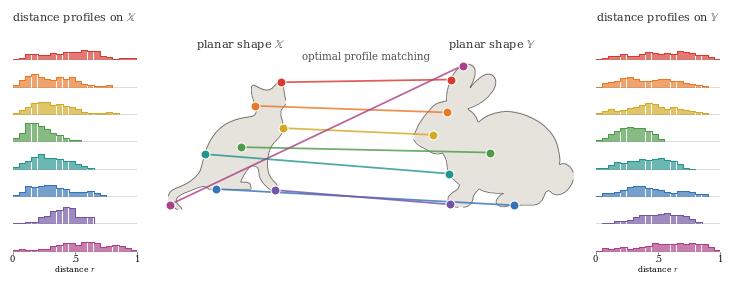

profile lower bound: 0.098858
GW value of the profile assignment: 0.233738
representative source indices: [2, 7, 5, 0, 6, 4, 3, 1]
matched target indices: [112, 121, 154, 292, 65, 5, 4, 2]
minimum pairwise spacing: cat=0.0222 bunny=0.0320


In [6]:
def render_figure() -> plt.Figure:
    """Compose and export the cat/bunny Mémoli-profile illustration.

    Returns:
        Matplotlib figure with two profile stacks, two silhouettes, and eight
        representative profile-assignment segments.
    """
    figure = plt.figure(figsize=(7.25, 2.82), facecolor="white")

    histogram_width = 0.172
    left_histogram_x = 0.012
    right_histogram_x = 1.0 - left_histogram_x - histogram_width
    histogram_bottom = 0.125
    histogram_height = 0.077
    histogram_gap = 0.020

    for row in range(N_REPRESENTATIVES):
        y_position = (
            histogram_bottom
            + (N_REPRESENTATIVES - 1 - row)
            * (histogram_height + histogram_gap)
        )
        left_ax = figure.add_axes(
            [left_histogram_x, y_position, histogram_width, histogram_height]
        )
        right_ax = figure.add_axes(
            [right_histogram_x, y_position, histogram_width, histogram_height]
        )
        show_axis = row == N_REPRESENTATIVES - 1
        draw_profile_card(
            left_ax,
            SOURCE_HISTOGRAMS[row],
            PAIR_COLORS[row],
            show_axis,
        )
        draw_profile_card(
            right_ax,
            TARGET_HISTOGRAMS[row],
            PAIR_COLORS[row],
            show_axis,
        )

    central_ax = figure.add_axes([0.192, 0.105, 0.616, 0.80])
    source_display, source_extent = display_geometry(CAT, center_x=-0.91, scale=1.20)
    target_display, target_extent = display_geometry(BUNNY, center_x=0.91, scale=1.20)
    draw_silhouette(central_ax, CAT, source_extent)
    draw_silhouette(central_ax, BUNNY, target_extent)

    selected_source_display = source_display[representative_source]
    selected_target_display = target_display[representative_target]
    for pair_index, color in enumerate(PAIR_COLORS):
        source_point = selected_source_display[pair_index]
        target_point = selected_target_display[pair_index]
        central_ax.plot(
            [source_point[0], target_point[0]],
            [source_point[1], target_point[1]],
            color=color,
            lw=1.25,
            alpha=0.82,
            solid_capstyle="round",
            zorder=3,
        )

    for selected_points in (selected_source_display, selected_target_display):
        for point, color in zip(selected_points, PAIR_COLORS):
            central_ax.scatter(
                [point[0]],
                [point[1]],
                s=42,
                color=color,
                edgecolor="white",
                linewidth=0.75,
                zorder=5,
            )

    central_ax.text(
        -0.91,
        0.69,
        r"planar shape $\mathbb{X}$",
        ha="center",
        va="bottom",
        fontsize=8.2,
        color="#34312d",
    )
    central_ax.text(
        0.91,
        0.69,
        r"planar shape $\mathbb{Y}$",
        ha="center",
        va="bottom",
        fontsize=8.2,
        color="#34312d",
    )
    central_ax.text(
        0.0,
        0.62,
        r"optimal profile matching",
        ha="center",
        va="bottom",
        fontsize=7.4,
        color=GRAY,
    )
    central_ax.set_xlim(-1.62, 1.62)
    central_ax.set_ylim(-0.70, 0.74)
    central_ax.set_aspect("equal")
    remove_axes(central_ax)

    figure.text(
        left_histogram_x + 0.5 * histogram_width,
        0.930,
        r"distance profiles on $\mathbb{X}$",
        ha="center",
        va="bottom",
        fontsize=8.0,
        color="#34312d",
    )
    figure.text(
        right_histogram_x + 0.5 * histogram_width,
        0.930,
        r"distance profiles on $\mathbb{Y}$",
        ha="center",
        va="bottom",
        fontsize=8.0,
        color="#34312d",
    )
    save_pdf(figure, OUT / "profiles.pdf", pad_inches=0.035)
    THUMBNAIL.parent.mkdir(parents=True, exist_ok=True)
    figure.savefig(
        THUMBNAIL,
        dpi=220,
        bbox_inches="tight",
        pad_inches=0.04,
        facecolor="white",
    )
    return figure


FIGURE = render_figure()
plt.show()

print(f"profile lower bound: {PROFILE_LOWER_BOUND:.6f}")
print(f"GW value of the profile assignment: {PROFILE_MAP_GW_VALUE:.6f}")
print("representative source indices:", representative_source.tolist())
print("matched target indices:", representative_target.tolist())
print(
    "minimum pairwise spacing:",
    f"cat={np.min(D_X[D_X > 0]):.4f}",
    f"bunny={np.min(D_Y[D_Y > 0]):.4f}",
)

## Figure preview

The generated thumbnail is embedded below so the final one-line layout can be inspected directly on GitHub.

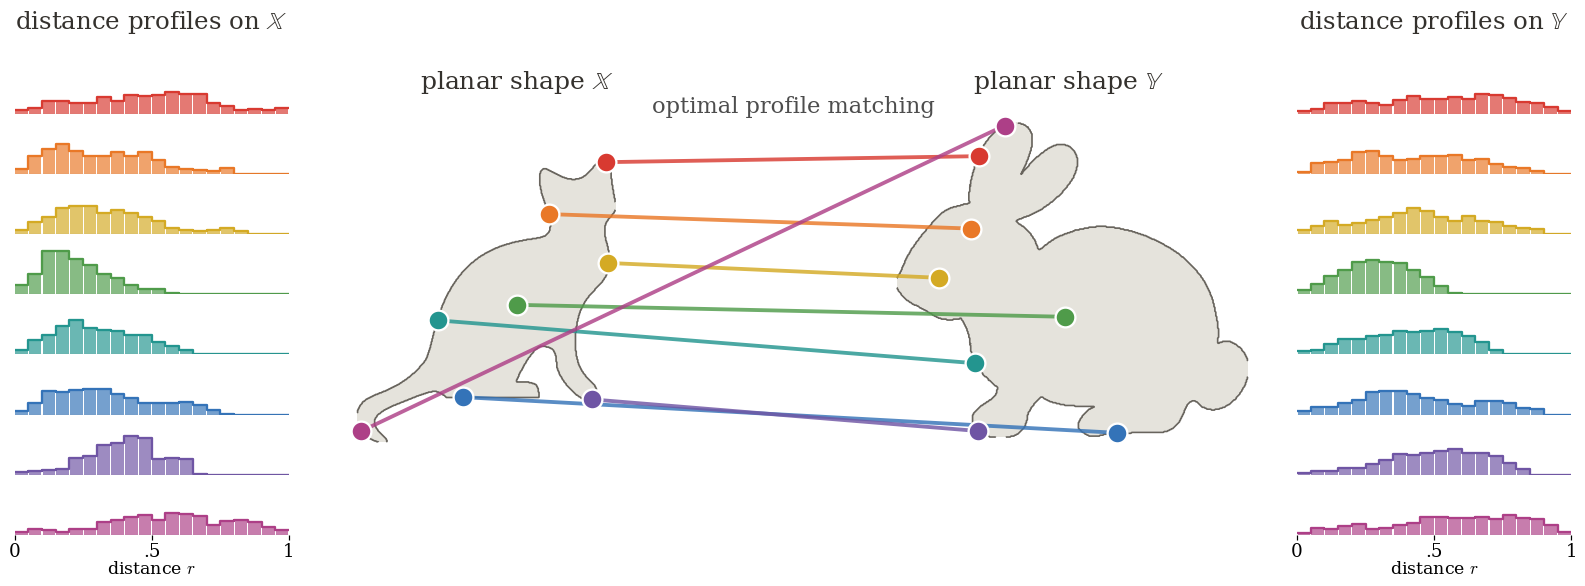

In [7]:
from IPython.display import Image as DisplayImage, display

display(DisplayImage(filename=str(THUMBNAIL)))